In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import linregress

from ase import Atoms, units
from ase.constraints import FixAtoms
from ase.io import read, Trajectory
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.npt import NPT
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase.calculators.calculator import Calculator, all_properties
from ase.neighborlist import neighbor_list
from ase.optimize import BFGS
from ase.eos import EquationOfState

# ============================================================
# PHYSICAL BASELINE VALUES INITIALIZATION
# ============================================================
ATOMIC_REFS = {
    8: -14.4981, 39: 3.8160, 40: 1.0342, 41: 2.1881,
    57: 5.6295,  58: 2.8697, 60: 5.8286, 63: 1.8170,
    64: -3.1563, 71: 5.7609, 90: 0.0736, 91: -2.4681,
    92: -3.1598, 93: -3.6084, 94: -4.5609, 95: -5.4599,
    96: -7.2799, 98: -6.5734
}
MAX_Z = max(ATOMIC_REFS.keys())
REF_LOOKUP = np.zeros(MAX_Z + 1, dtype=np.float32)
for z, ref_val in ATOMIC_REFS.items():
    REF_LOOKUP[z] = ref_val


def canonical_atom_order(atoms):
    """
    MUST match dataset.py's canonical_atom_order exactly, or the CNN branch
    sees a different atom-to-grid-slot mapping at inference than it was
    trained on. Primary key: species. Secondary: distance from centroid
    (PBC-wrapped). Tertiary: original index, for a deterministic tie-break.

    NOTE: this is a non-differentiable, discrete operation (np.lexsort).
    It is computed on detached/numpy positions -- see the discontinuity-at-
    ties finding from testing: a configuration that crosses a tie in this
    key will produce a discrete jump in matrix_images, and therefore in the
    energy/forces this calculator returns, at that exact geometry. This is
    an accepted, known limitation of keeping this ordering approach.
    """
    Z = atoms.get_atomic_numbers()
    pos = atoms.get_positions(wrap=True)
    centroid = pos.mean(axis=0, keepdims=True)
    d_centroid = np.linalg.norm(pos - centroid, axis=-1)
    order = np.lexsort((np.arange(len(Z)), d_centroid, Z))
    return order


# ============================================================
# CONSERVATIVE AUTOGRAD-SAFE TORCHSCRIPT CALCULATOR WRAPPER
# ============================================================
class CompiledMLIPCalculator(Calculator):
    implemented_properties = ['energy', 'forces']

    def __init__(self, compiled_model_path, device=torch.device("cpu"), r_cut=7.0):
        super().__init__()
        print(f"📦 Loading pre-compiled graph into memory stream: {compiled_model_path}")
        cpu_model = torch.jit.load(compiled_model_path, map_location="cpu")
        self.model = cpu_model.float().eval()
        self.device = device
        self.r_cut = r_cut

    def calculate(self, atoms=None, properties=['energy'], system_changes=all_properties):
        super().calculate(atoms, properties, system_changes)

        num_atoms = len(self.atoms)
        atomic_numbers_raw = self.atoms.get_atomic_numbers()

        # --------------------------------------------------------
        # 0. CANONICAL ORDER -- must match dataset.py's preprocessing.
        #    Computed once, from detached/numpy data. `order[k]` = which
        #    RAW atom index occupies canonical slot k.
        # --------------------------------------------------------
        order = canonical_atom_order(self.atoms)
        order_t = torch.tensor(order, dtype=torch.long, device=self.device)

        # A separate ASE Atoms view in canonical order, used ONLY for
        # topology (neighbor_list needs real Atoms/cell/pbc) -- this gives
        # edge_index directly in canonical indexing, exactly as dataset.py
        # does (it also calls neighbor_list AFTER reordering atoms).
        atoms_canon = self.atoms[order]

        # --------------------------------------------------------
        # 1. Enable Autograd Tape on ORIGINAL (raw-order) positions.
        #    Canonical-order views are built via index_select on this same
        #    tensor below, so autograd.grad at the end returns gradients
        #    already in the ORIGINAL atom order -- no manual un-permute
        #    of forces is needed.
        # --------------------------------------------------------
        positions = torch.tensor(self.atoms.get_positions(), dtype=torch.float32, device=self.device)
        positions.requires_grad_(True)

        pos_canon = positions[order_t]   # differentiable index_select, NOT a detached copy

        atomic_numbers_canon = atomic_numbers_raw[order]
        atomic_numbers_tensor = torch.tensor(atomic_numbers_canon, dtype=torch.long, device=self.device)

        # --------------------------------------------------------
        # 2. Neighbor list computed directly on the canonical-order Atoms,
        #    so edge_index/displacements are already canonically indexed.
        # --------------------------------------------------------
        idx_i, idx_j, displacements = neighbor_list('ijD', atoms_canon, self.r_cut)
        edge_index = torch.tensor(np.stack([idx_i, idx_j]), dtype=torch.long, device=self.device)
        edge_vec = torch.tensor(displacements, dtype=torch.float32, device=self.device)

        # Re-anchor dynamic distance vectors to the differentiable canonical positions
        dr_open = pos_canon[edge_index[1]] - pos_canon[edge_index[0]]
        with torch.no_grad():
            cell_offsets = edge_vec - dr_open
        dynamic_edge_vec = dr_open + cell_offsets

        # --------------------------------------------------------
        # 3. Pure PyTorch Distance Matrix & Smooth Cutoff Envelope (C^1 Continuous)
        # --------------------------------------------------------
        distances = torch.norm(dynamic_edge_vec, dim=-1)

        envelope = 0.5 * (torch.cos(np.pi * distances / self.r_cut) + 1.0)
        envelope = torch.where(distances < self.r_cut, envelope, torch.zeros_like(envelope))
        enveloped_distances = distances * envelope

        dist_matrix = torch.zeros((num_atoms, num_atoms), dtype=torch.float32, device=self.device)
        if len(idx_i) > 0:
            dist_matrix[edge_index[0], edge_index[1]] = enveloped_distances

        eye = torch.eye(num_atoms, dtype=torch.float32, device=self.device)
        dist_matrix = dist_matrix + eye

        # --------------------------------------------------------
        # 4. Spin Processing -- also reordered into canonical slots.
        #    Spin is a fixed (non-differentiated) input feature, same as in
        #    training, so plain numpy reindexing before tensor creation is
        #    consistent with dataset.py's treatment.
        # --------------------------------------------------------
        try:
            spin_np_raw = np.array(self.atoms.get_initial_magnetic_moments())
        except Exception:
            spin_np_raw = np.zeros(num_atoms)
        spin_np_raw = np.nan_to_num(spin_np_raw)
        spin_np = spin_np_raw[order]

        spin_t = torch.tensor(spin_np, dtype=torch.float32, device=self.device)

        spin_pair = torch.tanh(spin_t[:, None] * spin_t[None, :])
        spin_dist = spin_pair * torch.exp(-dist_matrix)

        diag_spin = torch.zeros_like(spin_pair)
        diag_spin.diagonal().copy_(spin_t)

        eps = 1e-8
        spin_pair_std = torch.std(spin_pair) + eps
        spin_dist_std = torch.std(spin_dist) + eps
        diag_spin_std = torch.std(diag_spin) + eps

        spin_pair = torch.tanh(spin_pair / spin_pair_std)
        spin_dist = torch.tanh(spin_dist / spin_dist_std)
        diag_spin = torch.tanh(diag_spin / diag_spin_std)

        channels = torch.stack([spin_pair, spin_dist, diag_spin], dim=0)
        matrix_images = torch.tanh(channels).unsqueeze(0)

        # matrix_mapping: arange is now CORRECT, because node k in every
        # other tensor (atomic_numbers_tensor, edge_index, pos_canon) is
        # ALSO canonical slot k -- consistent indexing throughout.
        matrix_mapping = torch.stack([
            torch.zeros(num_atoms, device=self.device),
            torch.arange(num_atoms, device=self.device)
        ], dim=-1).long()

        batch_indices = torch.zeros(num_atoms, dtype=torch.long, device=self.device)

        # --------------------------------------------------------
        # 5. Model Forward Pass -- every tensor passed in is canonically
        #    ordered and mutually consistent.
        # --------------------------------------------------------
        pred_energy, _ = self.model(
            pos_canon,
            atomic_numbers_tensor,
            edge_index,
            dynamic_edge_vec,
            matrix_images,
            matrix_mapping,
            batch_indices
        )
        pred_energy_flat = pred_energy.view(-1)

        # Baseline sum is order-independent (plain sum over atoms).
        baseline_energy = REF_LOOKUP[atomic_numbers_raw].sum()
        total_energy_ev = pred_energy_flat.item() + baseline_energy

        # --------------------------------------------------------
        # 6. Exact Analytical Autograd Forces: F = -dE/dr
        #    Differentiating w.r.t. the ORIGINAL `positions` tensor (not
        #    pos_canon) means autograd automatically scatters gradients
        #    back through the order_t index_select to the correct RAW
        #    atom indices -- the result is already in self.atoms' order,
        #    exactly what ASE expects. No manual un-permutation required.
        # --------------------------------------------------------
        forces_grad_tuple = torch.autograd.grad(
            outputs=pred_energy_flat,
            inputs=positions,
            grad_outputs=torch.ones_like(pred_energy_flat),
            create_graph=False,
            retain_graph=False,
            only_inputs=True
        )

        self.results['energy'] = total_energy_ev
        self.results['forces'] = -forces_grad_tuple[0].detach().cpu().numpy().astype(np.float64)

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import linregress

from ase import Atoms, units
from ase.io import read
from ase.constraints import FixCom
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

# Assumes CompiledMLIPCalculator is defined in your execution environment

def get_device():
    """Forces CPU execution to prevent TorchScript CPU-traced tensor mismatch."""
    return torch.device("cpu")

def build_amo2_cluster_from_cif(cif_path="AmO2.cif", supercell_dim=(1, 1, 1), radius_angstrom=None):
    """
    Loads AmO2 CIF, expands into a supercell, strips PBC, 
    and optionally trims into a spherical cluster.
    """
    if not os.path.exists(cif_path):
        raise FileNotFoundError(f"CIF file '{cif_path}' not found.")
    
    # 1. Load and replicate unit cell
    bulk = read(cif_path)
    supercell = bulk * supercell_dim
    
    # 2. Center atomic positions
    pos = supercell.get_positions()
    center_pt = pos.mean(axis=0)
    pos_centered = pos - center_pt

    # 3. Optional spherical trimming
    if radius_angstrom is not None:
        distances = np.linalg.norm(pos_centered, axis=1)
        mask = distances <= radius_angstrom
        cluster_symbols = np.array(supercell.get_chemical_symbols())[mask]
        cluster_positions = pos_centered[mask]
    else:
        cluster_symbols = supercell.get_chemical_symbols()
        cluster_positions = pos_centered

    # 4. Construct non-periodic cluster (pbc=False) with non-interacting vacuum padding
    cluster = Atoms(symbols=cluster_symbols, positions=cluster_positions, pbc=False)
    cluster.center(vacuum=12.0)
    return cluster

def run_single_nve_timestep(calc, cif_path, seed=42, dt_fs=0.5, temp_K=300.0, total_ps=2.0):
    """Runs NVE trajectory for a finite non-periodic AmO2 cluster."""
    cluster = build_amo2_cluster_from_cif(cif_path=cif_path, supercell_dim=(1, 1, 1))
    cluster.calc = calc
    num_atoms = len(cluster)
    nve_steps = int((total_ps * 1000.0) / dt_fs)

    # Velocity initialization & Center-of-Mass fix for non-periodic clusters
    MaxwellBoltzmannDistribution(cluster, temperature_K=temp_K, rng=np.random.RandomState(seed))
    Stationary(cluster)
    cluster.set_constraint(FixCom())

    # NVT Pre-equilibration
    nvt = Langevin(cluster, timestep=dt_fs * units.fs, temperature_K=temp_K, friction=0.02, fixcm=False)
    nvt.run(steps=int(2000 / dt_fs))

    # NVE Production Run
    dyn_nve = VelocityVerlet(cluster, timestep=dt_fs * units.fs)
    time_track, tot_track, kin_track = [], [], []

    def log_step():
        epot = cluster.get_potential_energy() / num_atoms
        ekin = cluster.get_kinetic_energy() / num_atoms
        etot = epot + ekin
        step = dyn_nve.get_number_of_steps()
        t_ps = step * dt_fs / 1000.0
        
        time_track.append(t_ps)
        tot_track.append(etot)
        kin_track.append(ekin)

    log_int = max(1, int(100 / (dt_fs / 0.5)))
    dyn_nve.attach(log_step, interval=log_int)
    dyn_nve.run(steps=nve_steps)

    t_arr = np.array(time_track)
    tot_arr = np.array(tot_track)
    kin_arr = np.array(kin_track)

    slope, _, _, _, _ = linregress(t_arr, tot_arr)
    drift_rate = slope * 1000.0  # meV/atom/ps
    fluct_ratio = np.std(tot_arr) / np.std(kin_arr)

    return t_arr, tot_arr, drift_rate, fluct_ratio

def setup_publication_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 7.5,      # Clean presentation match
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.2,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05
    })

def generate_amo2_cluster_figure(cif_path="AmO2.cif", timesteps=[1.0, 0.5, 0.25], seeds=[42, 101, 202], output_filename="amo2_cluster_NVE.pdf"):
    device = get_device()
    calc = CompiledMLIPCalculator("KENJI.ptc", device=device, r_cut=5.0)
    
    setup_publication_style()

    results = {}
    print("=" * 70)
    print("⏱️ Benchmark: Timestep & Seed Dependence of Non-Periodic AmO2 Cluster Energy Conservation")
    print("=" * 70)

    for dt in timesteps:
        results[dt] = {'drifts': [], 'flucts': [], 'time': None, 'etot': None}
        print(f"\n▶ Evaluating Timestep Δt = {dt} fs...")
        for s in seeds:
            t_arr, tot_arr, drift, fluct = run_single_nve_timestep(calc, cif_path, seed=s, dt_fs=dt)
            results[dt]['drifts'].append(drift)
            results[dt]['flucts'].append(fluct)
            
            # Store primary trajectory line for Panel A
            if s == seeds[0]:
                results[dt]['time'] = t_arr
                results[dt]['etot'] = tot_arr
            print(f"   Seed {s:3d} | Drift: {drift:10.6f} meV/atom/ps | Fluct Ratio: {fluct:8.6f}")

    # Plotting Grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8), gridspec_kw={'width_ratios': [2.0, 1.0]})
    colors = {0.25: '#2ca02c', 0.5: '#1f77b4', 1.0: '#d62728'}

    # Panel A: Trajectory comparison across timesteps
    for dt in timesteps:
        t = results[dt]['time']
        e_rel = (results[dt]['etot'] - results[dt]['etot'][0]) * 1000.0
        mean_drift = np.mean(results[dt]['drifts'])
        ax1.plot(t, e_rel, color=colors[dt], alpha=0.85, label=f"$\\Delta t = {dt}$ fs ({mean_drift:.3f} meV/atom/ps)")

    ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax1.set_xlabel(r"Time $t$ (ps)")
    ax1.set_ylabel(r"$\Delta E_{\mathrm{tot}}$ (meV/atom)")
    ax1.set_title(r"$\mathrm{CmO}_2$ Cluster Trajectories", loc='left', fontsize=9)
    
    # MODIFIED: Re-activated and moved label box to upper right with padding limits
    ax1.legend(
        frameon=True, 
        loc="upper right", 
        borderpad=0.4, 
        labelspacing=0.3,
        handletextpad=0.5
    )
    ax1.grid(True, linestyle=":", alpha=0.5)

    # Panel B: Multi-seed Bar Plot with Standard Errors
    mean_drifts = [np.mean(results[dt]['drifts']) for dt in timesteps]
    std_drifts = [np.std(results[dt]['drifts']) for dt in timesteps]

    x_pos = np.arange(len(timesteps))
    dt_labels = [f"{dt} fs" for dt in timesteps]

    ax2.bar(x_pos, mean_drifts, yerr=std_drifts, capsize=4, color=[colors[dt] for dt in timesteps], alpha=0.8, edgecolor='black', linewidth=0.8)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(dt_labels)
    ax2.set_ylabel(r"Mean Drift Rate $\gamma_E$ (meV/atom/ps)")
    ax2.set_title(r"Timestep Scaling", loc='left', fontsize=9)
    ax2.grid(True, linestyle=":", alpha=0.5, axis='y')

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.savefig(output_filename.replace(".pdf", ".png"))
    print(f"\n✅ Figure saved successfully to: {output_filename}")
    plt.show()

if __name__ == "__main__":
    generate_amo2_cluster_figure(cif_path="AmO2.cif")


📦 Loading pre-compiled graph into memory stream: KENJI.ptc
⏱️ Benchmark: Timestep & Seed Dependence of Non-Periodic AmO2 Cluster Energy Conservation

▶ Evaluating Timestep Δt = 1.0 fs...
   Seed  42 | Drift:  10.657813 meV/atom/ps | Fluct Ratio: 1.136515


KeyboardInterrupt: 

In [ ]:
"""
Minimal permutation check for the current (canonical-order + 3x3 CNN) setup.

Builds a simple structure, computes energy/forces, swaps two atoms' raw
listing order, recomputes, and prints the difference. Since the calculator
applies canonical_atom_order internally before the forward pass, this
should come back with E and F identical to machine precision -- *provided*
the swapped atoms don't happen to sit on either side of a sort-key tie
(see the Remark/Part 3 discussion: exact/near ties are the one case where
this invariance is not expected to hold).

Assumes CompiledMLIPCalculator and canonical_atom_order are already defined
(same cell/session as the rest of this project).
"""
import numpy as np
from ase import Atoms

MODEL_PATH = "KENJI.ptc"
R_CUT = 5.0


def build_simple_structure():
    positions = np.array([
        [0.0, 0.0, 0.0],
        [2.5, 2.5, 2.5],
        [1.2, 1.2, 1.2],
        [1.3, 1.2, -1.2],
        [3.5, 0.5, 0.5],
        [0.5, 3.5, 0.5],
    ])
    symbols = ['Am', 'Am', 'O', 'O', 'O', 'O']
    atoms = Atoms(symbols=symbols, positions=positions, cell=[5.0, 5.0, 5.0], pbc=True)
    atoms.set_initial_magnetic_moments([4.0, 4.0, 0.3, 0.32, 0.05, 0.05])
    return atoms


def swap_atoms(atoms, i, j):
    """Returns a copy of `atoms` with raw listing positions i and j swapped."""
    swapped = atoms.copy()
    order = np.arange(len(atoms))
    order[i], order[j] = order[j], order[i]
    return swapped[order]


def run_permutation_check(atoms, calc, i=2, j=3):
    print("=" * 70)
    print(f"Permutation check: swapping raw atom indices {i} and {j}")
    print("=" * 70)

    atoms_orig = atoms.copy()
    atoms_swapped = swap_atoms(atoms, i, j)

    atoms_orig.calc = calc
    e_orig = atoms_orig.get_potential_energy()
    f_orig = atoms_orig.get_forces()

    atoms_swapped.calc = calc
    e_swapped = atoms_swapped.get_potential_energy()
    f_swapped_raw = atoms_swapped.get_forces()

    # f_swapped_raw is in the SWAPPED listing order -- undo the swap so we
    # compare forces atom-for-atom against the original listing.
    unswap = np.arange(len(atoms))
    unswap[i], unswap[j] = unswap[j], unswap[i]
    f_swapped = f_swapped_raw[unswap]

    e_diff = abs(e_orig - e_swapped)
    f_diff = np.abs(f_orig - f_swapped)

    print(f"\n  E (original order) = {e_orig:.8f} eV")
    print(f"  E (swapped order)  = {e_swapped:.8f} eV")
    print(f"  |E diff|           = {e_diff:.3e} eV\n")

    print(f"{'atom':>5} | {'component':>9} | {'F (orig)':>12} | {'F (swapped)':>12} | {'|diff|':>10}")
    for a in range(len(atoms)):
        for c, label in enumerate(['x', 'y', 'z']):
            print(f"{a:5d} | {label:>9} | {f_orig[a,c]:12.6f} | {f_swapped[a,c]:12.6f} | {f_diff[a,c]:10.2e}")

    max_f_diff = f_diff.max()
    print(f"\n  max |F diff| = {max_f_diff:.3e} eV/Angstrom")

    if e_diff < 1e-6 and max_f_diff < 1e-5:
        print("  PASS: energy and forces are invariant to this atom swap.")
    else:
        print("  DIFFERENCE DETECTED: this swap likely crossed a canonical-order")
        print("  tie for these two atoms -- see the known discontinuity limitation.")
    print()
    return e_diff, max_f_diff


if __name__ == "__main__":
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    calc = CompiledMLIPCalculator(MODEL_PATH, device=device, r_cut=R_CUT)

    atoms = build_simple_structure()
    run_permutation_check(atoms, calc, i=4, j=5)

Initializing CompiledMLIPCalculator on cpu...
📦 Loading pre-compiled graph into memory stream: KENJI.ptc
Loading data from val.xyz...
Evaluating Birch-Murnaghan EOS using KENJI across 2972 structures...
  [info] structure 0: non-cubic cell detected -- using the shape-agnostic V-ratio relation for 'a', not V^(1/3).
  [info] structure 1: non-cubic cell detected -- using the shape-agnostic V-ratio relation for 'a', not V^(1/3).
  [info] structure 2: non-cubic cell detected -- using the shape-agnostic V-ratio relation for 'a', not V^(1/3).
  Processed 100/2972 structures...
  Processed 200/2972 structures...
  Processed 300/2972 structures...
  Processed 400/2972 structures...
  Processed 500/2972 structures...
  Processed 600/2972 structures...
  Processed 700/2972 structures...
  Processed 800/2972 structures...
  Processed 900/2972 structures...
  Processed 1000/2972 structures...
  Processed 1100/2972 structures...
  Processed 1200/2972 structures...
  Processed 1300/2972 structures...

/var/folders/sf/rzs_l5x95mdg4gn573gbpv4h0000gp/T/ipykernel_12268/3631709758.py:160: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1753839011583/work/aten/src/ATen/native/ReduceOps.cpp:1839.)
  spin_pair_std = torch.std(spin_pair) + eps
/var/folders/sf/rzs_l5x95mdg4gn573gbpv4h0000gp/T/ipykernel_12268/3631709758.py:161: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1753839011583/work/aten/src/ATen/native/ReduceOps.cpp:1839.)
  spin_dist_std = torch.std(spin_dist) + eps
/var/folders/sf/rzs_l5x95mdg4gn573gbpv4h0000gp/T/ipykernel_12268/3631709758.py:162: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction 

  Processed 2800/2972 structures...
  Processed 2900/2972 structures...
  Processed 2972/2972 structures...

--- KENJI Birch-Murnaghan EOS Volume Results ---
MAE  : 47.6241 Å³
RMSE : 107.2874 Å³
R²   : 0.8943

--- KENJI Lattice Parameter 'a' Results ---
MAE  : 0.3733 Å
RMSE : 0.5165 Å
R²   : 0.8099
WORST 15 RESIDUALS FOR V0 (of 2966 structures)
rank |        DFT |      KENJI |   residual |    %err | n_atoms | species              |   min_gap | moments
   0 |    3585.65 |    5647.40 |   +2061.75 |  +57.5% |     280 | Am,C,H,N,O           |  4.62e-08 | max|mu|=0.00, nonzero=0/280
   1 |    3575.29 |    5631.08 |   +2055.79 |  +57.5% |     280 | Am,C,H,N,O           |  2.61e-08 | max|mu|=0.00, nonzero=0/280
   2 |    3584.64 |    5099.81 |   +1515.17 |  +42.3% |     280 | Am,C,H,N,O           |  2.81e-09 | max|mu|=0.00, nonzero=0/280
   3 |    3585.39 |    5051.08 |   +1465.69 |  +40.9% |     280 | Am,C,H,N,O           |  1.48e-07 | max|mu|=0.00, nonzero=0/280
   4 |    1947.85 |    3067.

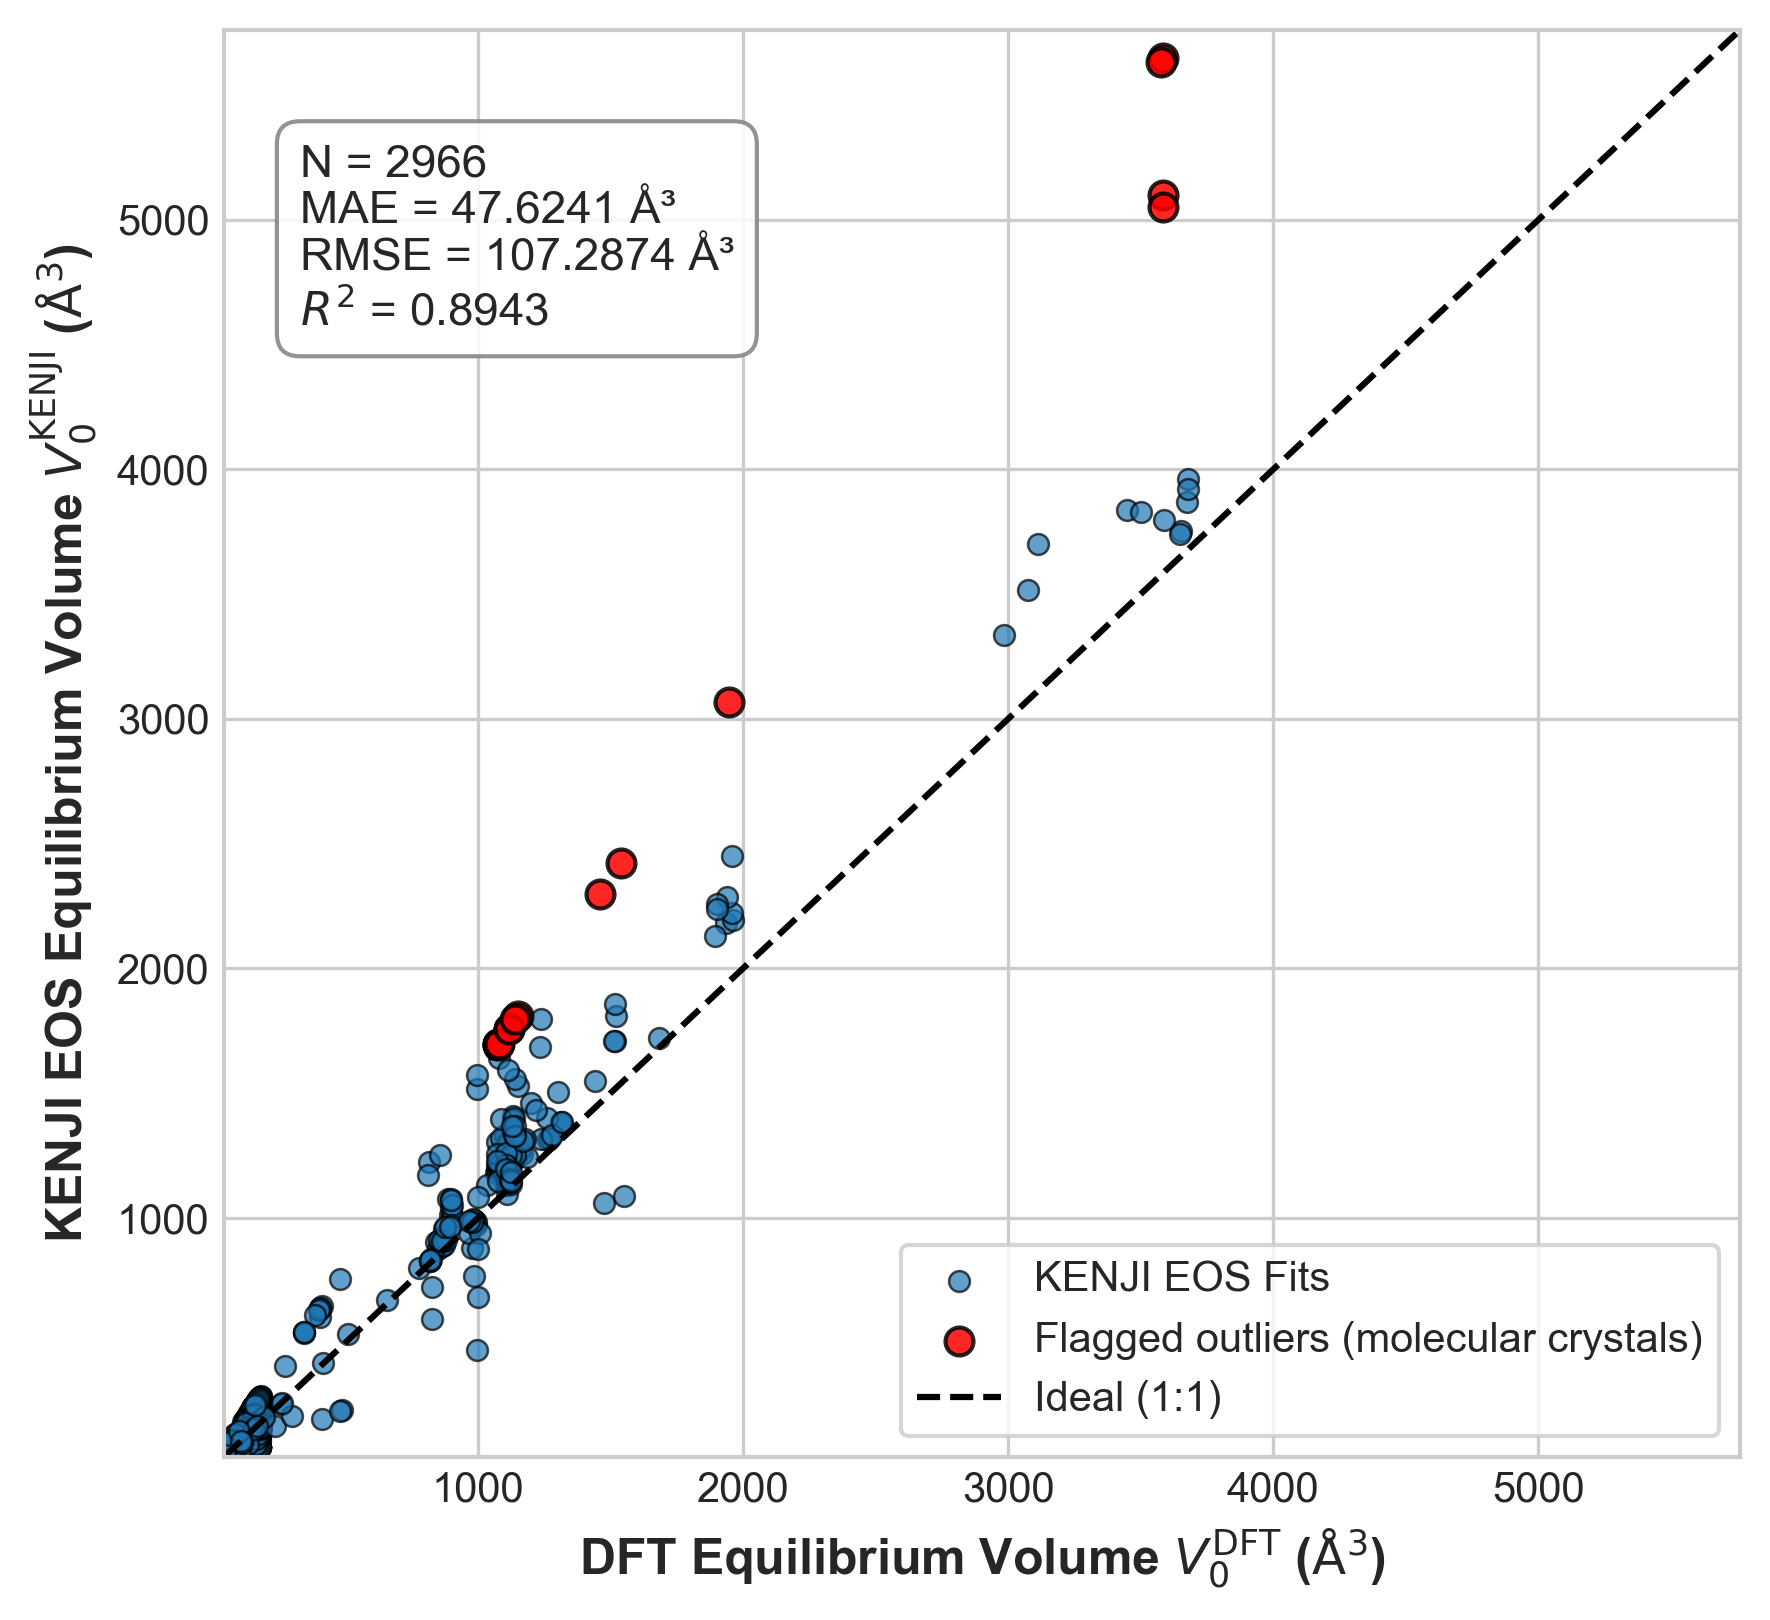

Saved plot as 'kenji_eos_lattice_parity.png' and 'kenji_eos_lattice_parity.pdf'.


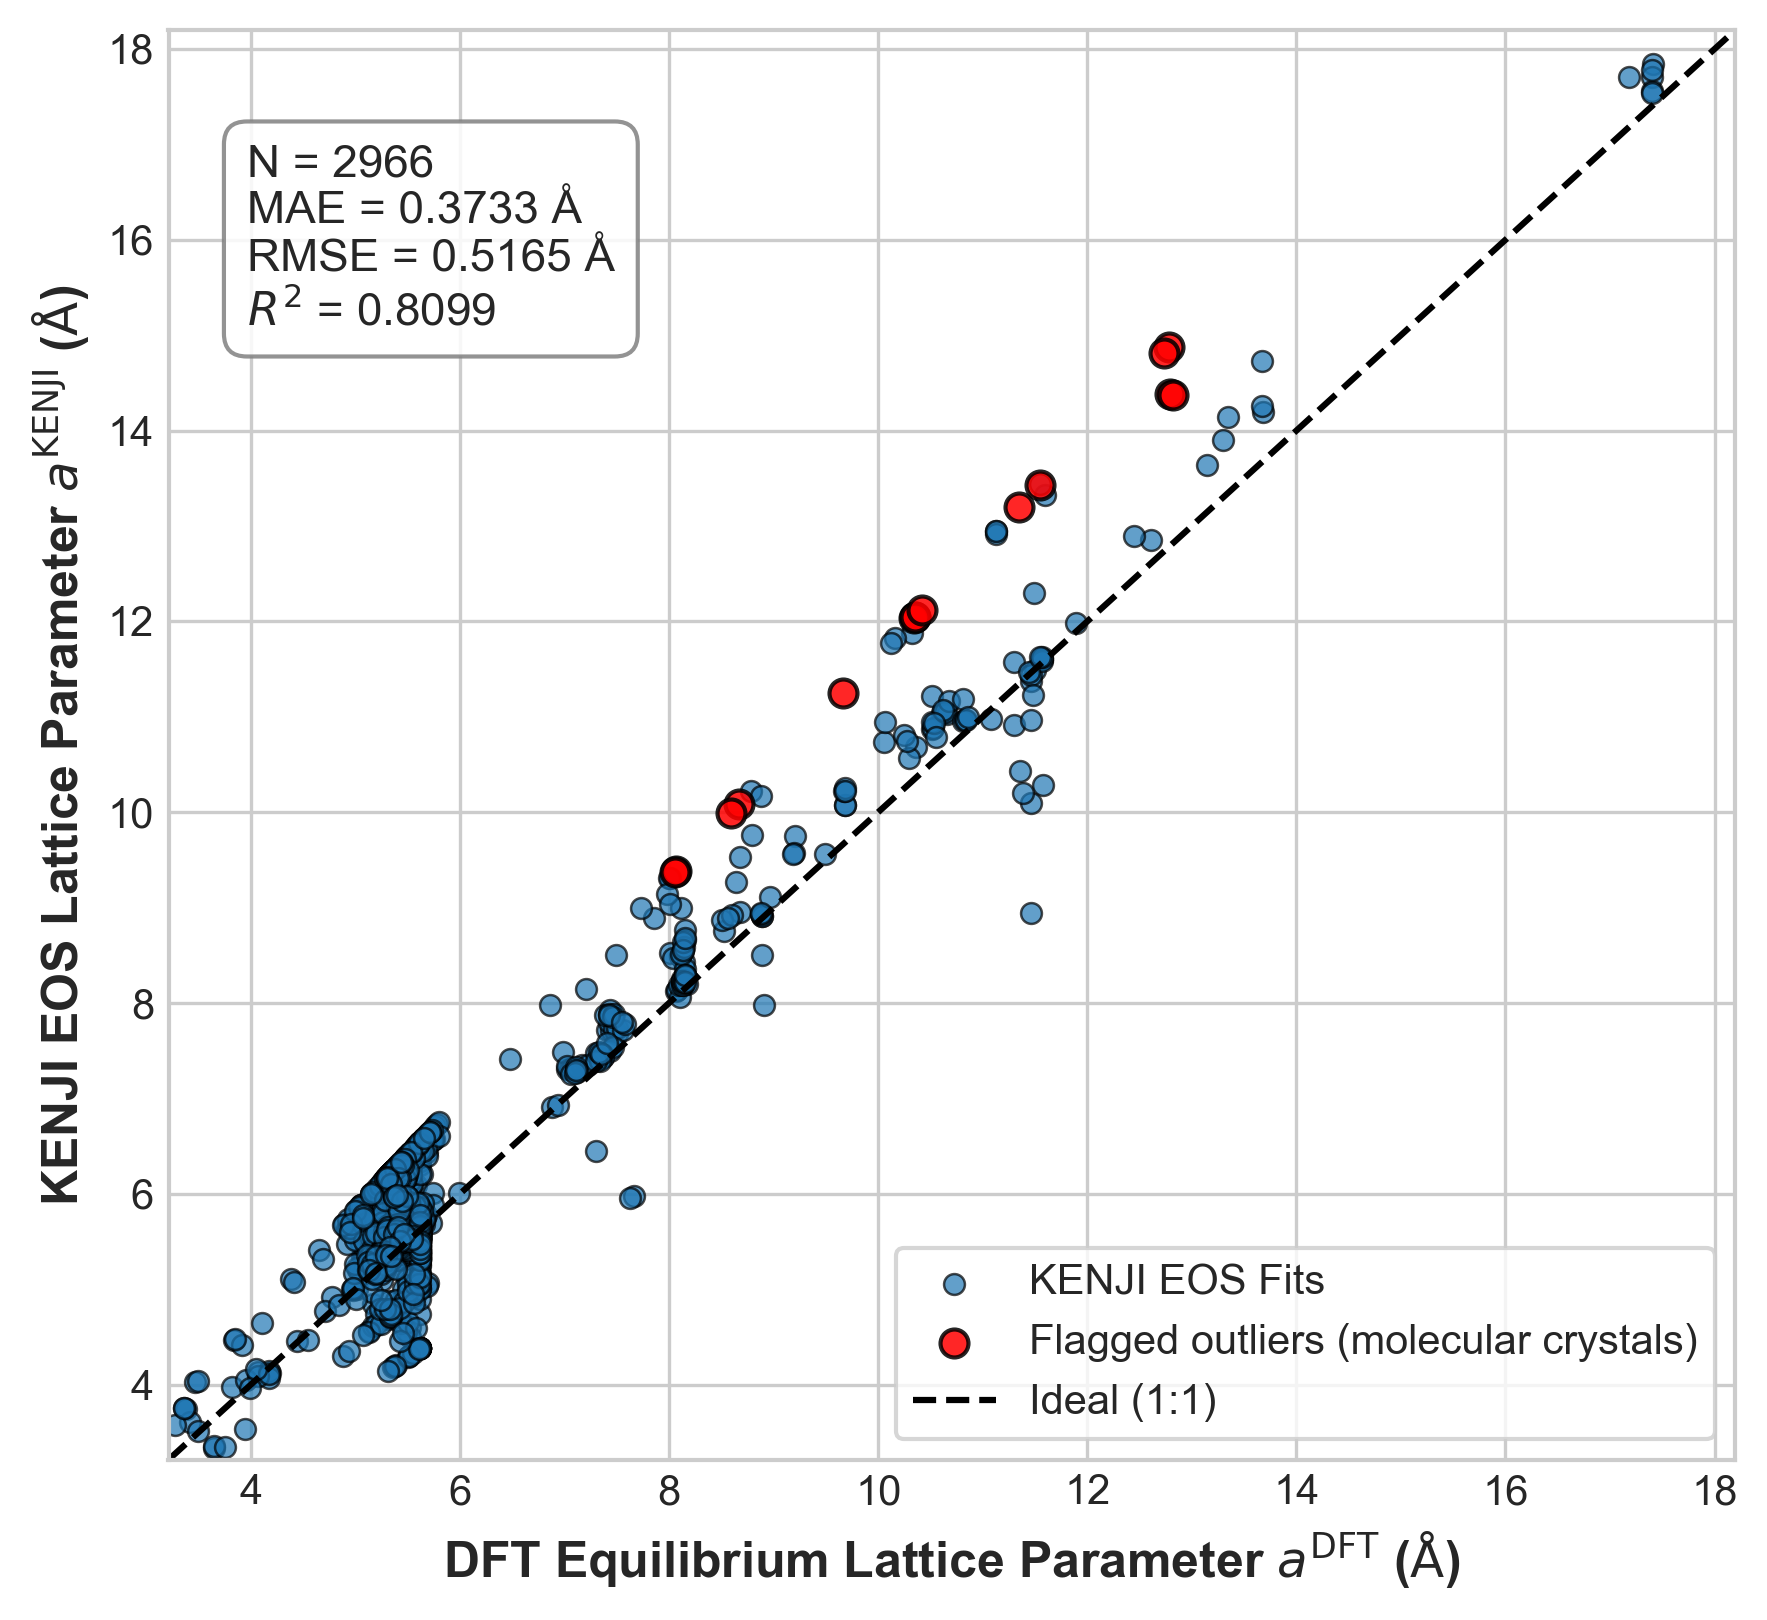

In [2]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from ase.io import read
from ase.neighborlist import neighbor_list

# ==============================================================================
# 1. BIRCH-MURNAGHAN EOS FITTER
# ==============================================================================
def birch_murnaghan(V, E0, V0, B0, B0_prime):
    """
    3rd-order Birch-Murnaghan Equation of State.
    V: Volume (Å³)
    E0: Equilibrium energy (eV)
    V0: Equilibrium volume (Å³)
    B0: Bulk modulus (eV/Å³)
    B0_prime: Pressure derivative of bulk modulus
    """
    eta = (V0 / V) ** (2.0 / 3.0)
    term = eta - 1.0
    E = E0 + (9.0 * V0 * B0 / 16.0) * (term**3 * B0_prime + (eta - 1.0)**2 * (6.0 - 4.0 * eta))
    return E

def fit_eos_volume(volumes, energies):
    """
    Fits V-E data to Birch-Murnaghan EOS and returns equilibrium volume V0.

    NOTE: an earlier version of this function automatically rejected (NaN'd)
    any fit whose V0 fell outside the sampled +/-5% strain window, intended
    to catch pathological cases (e.g. Am-DEHPA-type molecular crystals with
    no real minimum in-window). That check was too broad in practice: it
    also discarded legitimately-fit structures whose true equilibrium
    volume simply sits mildly outside the narrow sampled window (e.g. due
    to an ordinary small systematic offset between the DFT reference
    geometry and KENJI's own minimum) -- causing ~60% of structures to be
    silently dropped, which biases pooled metrics toward an unrepresentative
    "easy" subset. This is worse than reporting the honest, full-population
    number. We now fit every structure and report the full pooled result;
    the worst-residual cases (including genuine molecular-crystal failures)
    are identified and explained explicitly via analyze_outliers() instead
    of being silently excluded from the headline statistics.
    """
    v_min, idx = np.min(volumes), np.argmin(energies)
    v_max = np.max(volumes)
    p0 = [energies[idx], volumes[idx], 0.5, 4.0]  # Initial guess

    bounds = (
        [-np.inf, v_min * 0.5, 0.0, 0.0],
        [np.inf, v_max * 1.5, 10.0, 10.0]
    )

    try:
        popt, _ = curve_fit(birch_murnaghan, volumes, energies, p0=p0, bounds=bounds, maxfev=10000)
        _, V0_fit, _, _ = popt
        return V0_fit
    except Exception:
        return np.nan


def min_sort_key_gap(atoms):
    """
    Diagnostic for proximity to a canonical-order tie: computes the smallest
    gap in the (species, centroid-distance) sort key between any two atoms
    of the SAME species. A very small gap means this structure sits close
    to (or exactly on) a tie boundary -- relevant given the documented
    discontinuity at canonical-order flips for the 3x3 CNN branch.
    Returns np.inf if there are fewer than 2 atoms of any shared species.
    """
    Z = atoms.get_atomic_numbers()
    pos = atoms.get_positions(wrap=True)
    centroid = pos.mean(axis=0, keepdims=True)
    d = np.linalg.norm(pos - centroid, axis=-1)

    min_gap = np.inf
    for z in set(Z):
        d_z = np.sort(d[Z == z])
        if len(d_z) > 1:
            gaps = np.diff(d_z)
            min_gap = min(min_gap, gaps.min())
    return min_gap


def collect_structure_metadata(atoms):
    """Per-structure summary used for outlier diagnosis."""
    species = atoms.get_chemical_symbols()
    try:
        moments = np.asarray(atoms.get_initial_magnetic_moments())
        moment_summary = f"max|mu|={np.abs(moments).max():.2f}, nonzero={np.count_nonzero(moments)}/{len(moments)}"
    except Exception:
        moment_summary = "no moments set"
    return {
        "n_atoms": len(atoms),
        "species": sorted(set(species)),
        "moment_summary": moment_summary,
        "min_sort_key_gap": min_sort_key_gap(atoms),
    }


def analyze_outliers(kenji_vals, dft_vals, structures, label="V0", unit="Å³", top_n=15):
    """
    Reports the worst-residual structures with metadata, so large errors can
    be traced to a cause (size, species, magnetic state, or proximity to a
    canonical-order tie) rather than reported as unexplained scatter.
    """
    residuals = kenji_vals - dft_vals
    abs_residuals = np.abs(residuals)
    order = np.argsort(-abs_residuals)[:top_n]

    print("=" * 100)
    print(f"WORST {top_n} RESIDUALS FOR {label} (of {len(kenji_vals)} structures)")
    print("=" * 100)
    print(f"{'rank':>4} | {'DFT':>10} | {'KENJI':>10} | {'residual':>10} | {'%err':>7} | "
          f"{'n_atoms':>7} | {'species':<20} | {'min_gap':>9} | moments")
    for rank, idx in enumerate(order):
        meta = collect_structure_metadata(structures[idx])
        pct_err = 100 * residuals[idx] / dft_vals[idx]
        gap = meta["min_sort_key_gap"]
        gap_str = f"{gap:.2e}" if np.isfinite(gap) else "n/a"
        print(f"{rank:4d} | {dft_vals[idx]:10.2f} | {kenji_vals[idx]:10.2f} | "
              f"{residuals[idx]:+10.2f} | {pct_err:+6.1f}% | {meta['n_atoms']:7d} | "
              f"{','.join(meta['species']):<20} | {gap_str:>9} | {meta['moment_summary']}")

    # Quick aggregate check: do outliers skew toward large structures or
    # toward near-tie geometries, compared to the full population?
    all_n_atoms = np.array([len(a) for a in structures])
    all_gaps = np.array([min_sort_key_gap(a) for a in structures])
    outlier_n_atoms = all_n_atoms[order]
    outlier_gaps = all_gaps[order]

    print(f"\n  --- comparison: outliers vs. full population ---")
    print(f"  n_atoms      : outlier median={np.median(outlier_n_atoms):.0f}, "
          f"full median={np.median(all_n_atoms):.0f}")
    print(f"  min_gap      : outlier median={np.median(outlier_gaps[np.isfinite(outlier_gaps)]):.3e}, "
          f"full median={np.median(all_gaps[np.isfinite(all_gaps)]):.3e}")
    if np.median(outlier_n_atoms) > 1.5 * np.median(all_n_atoms):
        print("  -> Outliers skew toward LARGER structures than the general population.")
    if np.median(outlier_gaps[np.isfinite(outlier_gaps)]) < 0.5 * np.median(all_gaps[np.isfinite(all_gaps)]):
        print("  -> Outliers skew toward NEAR-TIE geometries (small sort-key gap) --")
        print("     consistent with the documented canonical-order discontinuity.")

    # Report metrics with and without the flagged outliers, for the writeup
    keep_mask = np.ones(len(kenji_vals), dtype=bool)
    keep_mask[order] = False
    mae_excl = np.mean(abs_residuals[keep_mask])
    rmse_excl = np.sqrt(np.mean(residuals[keep_mask] ** 2))
    r2_excl = 1 - np.sum(residuals[keep_mask] ** 2) / np.sum((dft_vals[keep_mask] - dft_vals[keep_mask].mean()) ** 2)
    print(f"\n  --- metrics excluding these {top_n} outliers ---")
    print(f"  MAE  : {mae_excl:.4f} {unit}  (full set: {abs_residuals.mean():.4f})")
    print(f"  RMSE : {rmse_excl:.4f} {unit}  (full set: {np.sqrt((residuals**2).mean()):.4f})")
    print(f"  R²   : {r2_excl:.4f}  (full set: {1 - np.sum(residuals**2)/np.sum((dft_vals-dft_vals.mean())**2):.4f})")

    return order


def lattice_param_from_cell(cell, axis=0):
    """
    Returns the length of the specified lattice vector (default: the first,
    i.e. the conventional 'a' parameter). Works for any cell shape -- no
    cubic assumption. `cell` can be an ase.cell.Cell or a (3,3) array.
    """
    cell = np.asarray(cell)
    return np.linalg.norm(cell[axis])


def is_cubic_cell(cell, tol=1e-3):
    """Optional diagnostic: reports whether a cell is (to tolerance) cubic."""
    cell = np.asarray(cell)
    lengths = np.linalg.norm(cell, axis=1)
    angles_ok = True
    for i in range(3):
        for j in range(i + 1, 3):
            cos_angle = np.dot(cell[i], cell[j]) / (lengths[i] * lengths[j])
            if abs(cos_angle) > tol:
                angles_ok = False
    lengths_ok = np.ptp(lengths) / lengths.mean() < tol
    return angles_ok and lengths_ok


# ==============================================================================
# 2. INITIALIZE KENJI CALCULATOR & DATA LOADER
# ==============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing CompiledMLIPCalculator on {device}...")
ken_calc = CompiledMLIPCalculator("KENJI.ptc", device=device, r_cut=7.0)


def load_data(file_path, lattice_axis=0):
    """
    Loads structures and reference DFT equilibrium volumes AND lattice
    parameters from .xyz or .pkl.

    Reference lattice parameter resolution order, per structure:
      1. atoms.info['dft_a'] if present -- most direct, no assumptions.
      2. Otherwise derived from atoms.info['dft_v0'] (or atoms.get_volume()
         if absent) via the shape-agnostic isotropic-scaling relation:
             a_dft = a_original * (V_dft / V_original)^(1/3)
         valid for ANY cell shape (not just cubic), since isotropic scaling
         multiplies volume by scale^3 regardless of crystal system.
    """
    structures = []
    dft_v0 = []
    dft_a = []

    ext = os.path.splitext(file_path)[-1].lower()
    print(f"Loading data from {file_path}...")

    def resolve_a(atoms, v0_val):
        a_original = lattice_param_from_cell(atoms.get_cell(), axis=lattice_axis)
        v_original = atoms.get_volume()
        info_a = atoms.info.get('dft_a', None) if hasattr(atoms, 'info') else None
        if info_a is not None:
            return float(info_a)
        # fallback: shape-agnostic scaling relation, no cubic assumption
        scale = (v0_val / v_original) ** (1.0 / 3.0)
        return a_original * scale

    if ext in ['.xyz', '.extxyz']:
        frames = read(file_path, index=':')
        for atoms in frames:
            structures.append(atoms)
            v0_val = atoms.info.get('dft_v0', atoms.get_volume())
            dft_v0.append(v0_val)
            dft_a.append(resolve_a(atoms, v0_val))

    elif ext == '.pkl':
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        if isinstance(data, pd.DataFrame):
            for _, row in data.iterrows():
                atoms = row['atoms'] if 'atoms' in row else row['structure']
                structures.append(atoms)
                v0_val = row.get('dft_v0', atoms.get_volume())
                dft_v0.append(v0_val)
                a_val = row.get('dft_a', None)
                dft_a.append(float(a_val) if a_val is not None else resolve_a(atoms, v0_val))
        elif isinstance(data, list):
            for item in data:
                if isinstance(item, dict):
                    atoms = item['atoms']
                    v0_val = item.get('dft_v0', atoms.get_volume())
                    a_val = item.get('dft_a', None)
                else:
                    atoms = item
                    v0_val = atoms.info.get('dft_v0', atoms.get_volume())
                    a_val = atoms.info.get('dft_a', None)
                structures.append(atoms)
                dft_v0.append(v0_val)
                dft_a.append(float(a_val) if a_val is not None else resolve_a(atoms, v0_val))

    return structures, np.array(dft_v0), np.array(dft_a)


# ==============================================================================
# 3. EOS LATTICE-PARAMETER ANALYSIS WITH KENJI
# ==============================================================================
def is_periodic_crystal(atoms, cutoff=6.0, min_periodic_fraction=0.05):
    """
    atoms.get_pbc() alone is not reliable here: many pipelines set pbc=True
    on every structure (including isolated molecules placed in a large box)
    purely for data-loader compatibility, without the periodicity being
    physically real. Instead, check whether periodic images actually
    matter: build a neighbor list with periodic image-shift vectors and
    see whether any appreciable fraction of neighbor pairs have a NONZERO
    shift (i.e. the bond crosses a cell boundary to a periodic replica).
    If essentially all shifts are zero, every neighbor lies within the
    same unit cell image -- this is functionally an isolated
    molecule/cluster in a box, not a periodic crystal, regardless of the
    pbc flag, and the isotropic bulk-strain EOS protocol does not apply.
    """
    if not np.any(atoms.get_pbc()):
        return False  # no pbc at all -- definitely not periodic

    try:
        idx_i, idx_j, S = neighbor_list('ijS', atoms, cutoff)
    except Exception:
        return False

    if len(idx_i) == 0:
        return False  # no neighbors found at all -- can't be a bonded crystal

    nonzero_shift = np.any(S != 0, axis=-1)
    periodic_fraction = nonzero_shift.mean()
    return periodic_fraction >= min_periodic_fraction


def run_kenji_eos_analysis(file_path, strain_range=(-0.05, 0.05), num_points=9, lattice_axis=0):
    structures, dft_v0_list, dft_a_list = load_data(file_path, lattice_axis=lattice_axis)
    # NOTE: an earlier version filtered out structures whose periodicity
    # looked spurious (molecule-in-a-box). That hypothesis didn't hold up:
    # checking V/N (cell volume per atom) for the flagged outlier structures
    # gives ~12.8 A^3/atom -- a normal DENSE packing value, not the >30-50
    # A^3/atom typical of vacuum-padded isolated molecules. These are more
    # likely genuine periodic actinide organometallic/coordination-polymer
    # frameworks, where the Birch-Murnaghan EOS's assumption of a single,
    # fairly stiff, concave-up E-V well within a modest +/-5% strain window
    # can simply fail to hold (floppier framework compressibility, possible
    # non-monotonic behavior). The bound-saturation guard in fit_eos_volume
    # catches the resulting meaningless fits directly, regardless of WHY
    # the fit failed to converge to a real interior minimum -- so no
    # separate structure-type filter is needed here.
    kenji_v0_list = []
    kenji_a_list = []
    valid_dft_v0 = []
    valid_dft_a = []
    valid_structures = []
    n_noncubic_warned = 0

    strains = np.linspace(strain_range[0], strain_range[1], num_points)
    print(f"Evaluating Birch-Murnaghan EOS using KENJI across {len(structures)} structures...")

    for i, atoms in enumerate(structures):
        original_cell = atoms.get_cell()
        v_original = atoms.get_volume()
        a_original = lattice_param_from_cell(original_cell, axis=lattice_axis)

        if not is_cubic_cell(original_cell) and n_noncubic_warned < 3:
            print(f"  [info] structure {i}: non-cubic cell detected -- using the "
                  f"shape-agnostic V-ratio relation for 'a', not V^(1/3).")
            n_noncubic_warned += 1

        volumes = []
        energies = []

        # Isotropic Volume Strain (-5% to +5% volume); `scale` here is already
        # the LINEAR (lattice-parameter) scale factor, since it's the cube
        # root of the volumetric strain -- i.e. a(scale) = a_original * scale.
        for scale in (1.0 + strains) ** (1.0 / 3.0):
            strained_atoms = atoms.copy()
            strained_atoms.set_cell(original_cell * scale, scale_atoms=True)

            strained_atoms.calc = ken_calc
            energy = strained_atoms.get_potential_energy()

            volumes.append(strained_atoms.get_volume())
            energies.append(energy)

        V0_fit = fit_eos_volume(volumes, energies)

        if not np.isnan(V0_fit) and V0_fit > 0:
            # Shape-agnostic conversion from fitted equilibrium volume to
            # equilibrium lattice parameter: valid for any cell shape,
            # since isotropic scaling multiplies V by scale^3 always.
            scale0 = (V0_fit / v_original) ** (1.0 / 3.0)
            a0_fit = a_original * scale0

            kenji_v0_list.append(V0_fit)
            kenji_a_list.append(a0_fit)
            valid_dft_v0.append(dft_v0_list[i])
            valid_dft_a.append(dft_a_list[i])
            valid_structures.append(atoms)

        if (i + 1) % 100 == 0 or (i + 1) == len(structures):
            print(f"  Processed {i + 1}/{len(structures)} structures...")

    kenji_v0_list = np.array(kenji_v0_list)
    kenji_a_list = np.array(kenji_a_list)
    valid_dft_v0 = np.array(valid_dft_v0)
    valid_dft_a = np.array(valid_dft_a)

    def report_metrics(pred, ref, label, unit):
        mae = np.mean(np.abs(pred - ref))
        rmse = np.sqrt(np.mean((pred - ref) ** 2))
        r2 = 1 - (np.sum((ref - pred) ** 2) / np.sum((ref - np.mean(ref)) ** 2))
        print(f"\n--- KENJI {label} Results ---")
        print(f"MAE  : {mae:.4f} {unit}")
        print(f"RMSE : {rmse:.4f} {unit}")
        print(f"R²   : {r2:.4f}")
        return mae, rmse, r2

    v0_mae, v0_rmse, v0_r2 = report_metrics(kenji_v0_list, valid_dft_v0, "Birch-Murnaghan EOS Volume", "Å³")
    a_mae, a_rmse, a_r2 = report_metrics(kenji_a_list, valid_dft_a, "Lattice Parameter 'a'", "Å")

    # --------------------------------------------------------------------
    # OUTLIER DIAGNOSIS -- run before plotting so the outlier indices can
    # be used to highlight those points in the parity plot below.
    # --------------------------------------------------------------------
    outlier_idx = analyze_outliers(kenji_v0_list, valid_dft_v0, valid_structures,
                                    label="V0", unit="Å³", top_n=15)
    is_outlier = np.zeros(len(kenji_a_list), dtype=bool)
    is_outlier[outlier_idx] = True

    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

    # ==============================================================================
    # 4a. PUBLICATION-READY PARITY PLOT (equilibrium volume V0)
    # ==============================================================================
    fig_v, ax_v = plt.subplots(figsize=(6, 5.5), dpi=300)

    ax_v.scatter(valid_dft_v0[~is_outlier], kenji_v0_list[~is_outlier],
                 alpha=0.7, c='#1f77b4', edgecolors='black', linewidths=0.6,
                 s=25, marker='o', label='KENJI EOS Fits')

    ax_v.scatter(valid_dft_v0[is_outlier], kenji_v0_list[is_outlier],
                 alpha=0.85, c='red', edgecolors='black', linewidths=1.0,
                 s=45, marker='o', label='Flagged outliers (molecular crystals)', zorder=5)

    min_val_v = min(np.min(valid_dft_v0), np.min(kenji_v0_list)) * 0.98
    max_val_v = max(np.max(valid_dft_v0), np.max(kenji_v0_list)) * 1.02
    ax_v.plot([min_val_v, max_val_v], [min_val_v, max_val_v], 'k--', lw=1.5, label='Ideal (1:1)')

    ax_v.set_xlabel(r'DFT Equilibrium Volume $V_0^{\text{DFT}}$ ($\mathrm{\AA}^3$)', fontsize=12, fontweight='bold')
    ax_v.set_ylabel(r'KENJI EOS Equilibrium Volume $V_0^{\text{KENJI}}$ ($\mathrm{\AA}^3$)', fontsize=12, fontweight='bold')
    ax_v.set_xlim(min_val_v, max_val_v)
    ax_v.set_ylim(min_val_v, max_val_v)

    stats_text_v = f"N = {len(valid_dft_v0)}\nMAE = {v0_mae:.4f} Å³\nRMSE = {v0_rmse:.4f} Å³\n$R^2$ = {v0_r2:.4f}"
    ax_v.text(0.05, 0.92, stats_text_v, transform=ax_v.transAxes, fontsize=11,
              verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax_v.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.savefig('kenji_eos_volume_parity.png', dpi=300)
    plt.savefig('kenji_eos_volume_parity.pdf')
    print("Saved plot as 'kenji_eos_volume_parity.png' and 'kenji_eos_volume_parity.pdf'.")
    plt.show()

    # ==============================================================================
    # 4b. PUBLICATION-READY PARITY PLOT (lattice parameter a)
    # ==============================================================================
    fig_a, ax_a = plt.subplots(figsize=(6, 5.5), dpi=300)

    # Normal points: blue fill with a black circular boundary.
    ax_a.scatter(valid_dft_a[~is_outlier], kenji_a_list[~is_outlier],
                 alpha=0.7, c='#1f77b4', edgecolors='black', linewidths=0.6,
                 s=25, marker='o', label='KENJI EOS Fits')

    # Flagged outliers (largest-residual structures, e.g. Am-DEHPA-type
    # molecular crystals): red fill with a black circular boundary, drawn
    # larger and on top so they remain visually distinct from the general
    # population.
    ax_a.scatter(valid_dft_a[is_outlier], kenji_a_list[is_outlier],
                 alpha=0.85, c='red', edgecolors='black', linewidths=1.0,
                 s=45, marker='o', label='Flagged outliers (molecular crystals)', zorder=5)

    min_val = min(np.min(valid_dft_a), np.min(kenji_a_list)) * 0.98
    max_val = max(np.max(valid_dft_a), np.max(kenji_a_list)) * 1.02
    ax_a.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Ideal (1:1)')

    ax_a.set_xlabel(r'DFT Equilibrium Lattice Parameter $a^{\text{DFT}}$ ($\mathrm{\AA}$)', fontsize=12, fontweight='bold')
    ax_a.set_ylabel(r'KENJI EOS Lattice Parameter $a^{\text{KENJI}}$ ($\mathrm{\AA}$)', fontsize=12, fontweight='bold')
    ax_a.set_xlim(min_val, max_val)
    ax_a.set_ylim(min_val, max_val)

    stats_text = f"N = {len(valid_dft_a)}\nMAE = {a_mae:.4f} Å\nRMSE = {a_rmse:.4f} Å\n$R^2$ = {a_r2:.4f}"
    ax_a.text(0.05, 0.92, stats_text, transform=ax_a.transAxes, fontsize=11,
              verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax_a.legend(loc='lower right', frameon=True)
    plt.tight_layout()

    plt.savefig('kenji_eos_lattice_parity.png', dpi=300)
    plt.savefig('kenji_eos_lattice_parity.pdf')
    print("Saved plot as 'kenji_eos_lattice_parity.png' and 'kenji_eos_lattice_parity.pdf'.")
    plt.show()

    return {
        "kenji_v0": kenji_v0_list, "dft_v0": valid_dft_v0,
        "kenji_a": kenji_a_list, "dft_a": valid_dft_a,
        "structures": valid_structures,
        "outlier_idx": outlier_idx,
    }


if __name__ == "__main__":
    DATA_FILE = "val.xyz"  # Path to your .xyz or .pkl

    if os.path.exists(DATA_FILE):
        run_kenji_eos_analysis(DATA_FILE)
    else:
        print(f"File '{DATA_FILE}' not found. Please update DATA_FILE path.")

📦 Loading pre-compiled graph into memory stream: KENJI.ptc
⏱️ Benchmark: Timestep Dependence of (UO2)4 Cluster Energy Conservation

▶ Evaluating Timestep Δt = 0.25 fs...
  Seed  42 | Drift:  -0.006348 meV/atom/ps | Fluct Ratio: 0.214746
  Seed 101 | Drift:  -0.025513 meV/atom/ps | Fluct Ratio: 0.040573
  Seed 202 | Drift:   0.014636 meV/atom/ps | Fluct Ratio: 0.163139

▶ Evaluating Timestep Δt = 0.5 fs...
  Seed  42 | Drift:  -0.031635 meV/atom/ps | Fluct Ratio: 0.349940
  Seed 101 | Drift:   0.079966 meV/atom/ps | Fluct Ratio: 0.208180
  Seed 202 | Drift:  -0.010751 meV/atom/ps | Fluct Ratio: 0.065197

▶ Evaluating Timestep Δt = 1.0 fs...
  Seed  42 | Drift:  -0.041300 meV/atom/ps | Fluct Ratio: 0.051808
  Seed 101 | Drift:   0.026779 meV/atom/ps | Fluct Ratio: 0.165736
  Seed 202 | Drift:  -0.040700 meV/atom/ps | Fluct Ratio: 0.057768

✅ Publication figure saved successfully to: uo2_timestep_dependence.pdf


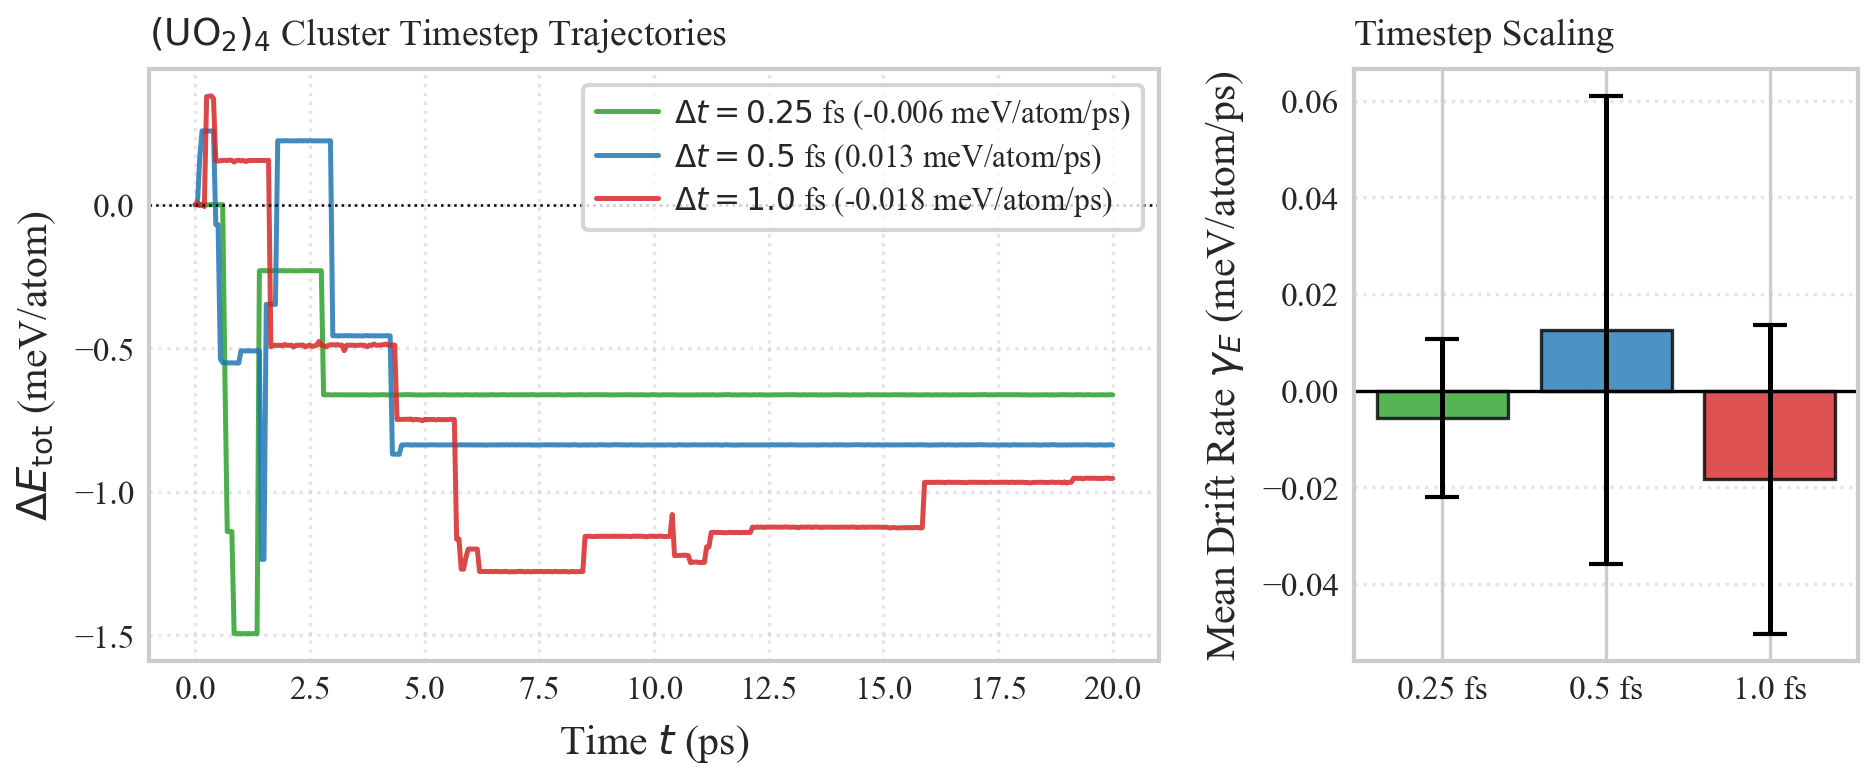

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import linregress
from ase import Atoms, units
from ase.constraints import FixCom
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

def build_uo2_cluster():
    """Builds a non-periodic cluster of 4 UO2 molecules (12 atoms)."""
    u_o_bond = 1.78
    centers = [
        [ -1.6,  -1.6,  0.0],
        [  1.6,  -1.6,  0.0],
        [ -1.6,   1.6,  0.0],
        [  1.6,   1.6,  0.0]
    ]
    all_symbols, all_positions = [], []
    for c in centers:
        cx, cy, cz = c
        all_symbols.extend(['O', 'U', 'O'])
        all_positions.extend([
            [cx, cy, cz - u_o_bond],
            [cx, cy, cz],
            [cx, cy, cz + u_o_bond]
        ])
    cluster = Atoms(symbols=all_symbols, positions=all_positions, pbc=False)
    cluster.center(vacuum=12.0)
    return cluster

def run_single_nve_timestep(calc, seed=42, dt_fs=0.5, temp_K=300.0, total_ps=20.0):
    """Runs NVE trajectory for a given seed and timestep."""
    cluster = build_uo2_cluster()
    cluster.calc = calc
    num_atoms = len(cluster)
    nve_steps = int((total_ps * 1000.0) / dt_fs)

    MaxwellBoltzmannDistribution(cluster, temperature_K=temp_K, rng=np.random.RandomState(seed))
    Stationary(cluster)
    cluster.set_constraint(FixCom())

    # NVT Pre-equilibration
    nvt = Langevin(cluster, timestep=dt_fs * units.fs, temperature_K=temp_K, friction=0.02, fixcm=False)
    nvt.run(steps=int(2000 / dt_fs))

    # NVE Production Run
    dyn_nve = VelocityVerlet(cluster, timestep=dt_fs * units.fs)
    time_track, tot_track, kin_track = [], [], []

    def log_step():
        epot = cluster.get_potential_energy() / num_atoms
        ekin = cluster.get_kinetic_energy() / num_atoms
        etot = epot + ekin
        step = dyn_nve.get_number_of_steps()
        t_ps = step * dt_fs / 1000.0
        time_track.append(t_ps)
        tot_track.append(etot)
        kin_track.append(ekin)

    # Log interval scales with timestep so logging frequency is equal in simulation time
    log_int = max(1, int(100 / (dt_fs / 0.5)))
    dyn_nve.attach(log_step, interval=log_int)
    dyn_nve.run(steps=nve_steps)

    t_arr = np.array(time_track)
    tot_arr = np.array(tot_track)
    kin_arr = np.array(kin_track)

    slope, _, _, _, _ = linregress(t_arr, tot_arr)
    drift_rate = slope * 1000.0  # meV/atom/ps
    fluct_ratio = np.std(tot_arr) / np.std(kin_arr)

    return t_arr, tot_arr, drift_rate, fluct_ratio

def setup_publication_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 7.5,      # Marginally reduced for compact presentation
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.2,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05
    })

def generate_timestep_figure(timesteps=[0.25, 0.5, 1.0], seeds=[42, 101, 202], output_filename="uo2_timestep_dependence.pdf"):
    calc = CompiledMLIPCalculator("KENJI.ptc", device=torch.device("cpu"), r_cut=5.0)
    setup_publication_style()

    results = {}
    print("=" * 70)
    print("⏱️ Benchmark: Timestep Dependence of (UO2)4 Cluster Energy Conservation")
    print("=" * 70)

    for dt in timesteps:
        results[dt] = {'drifts': [], 'flucts': [], 'time': None, 'etot': None}
        print(f"\n▶ Evaluating Timestep Δt = {dt} fs...")
        for s in seeds:
            t_arr, tot_arr, drift, fluct = run_single_nve_timestep(calc, seed=s, dt_fs=dt)
            results[dt]['drifts'].append(drift)
            results[dt]['flucts'].append(fluct)
            if s == seeds[0]:
                results[dt]['time'] = t_arr
                results[dt]['etot'] = tot_arr
            print(f"  Seed {s:3d} | Drift: {drift:10.6f} meV/atom/ps | Fluct Ratio: {fluct:8.6f}")

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8), gridspec_kw={'width_ratios': [2.0, 1.0]})
    colors = {0.25: '#2ca02c', 0.5: '#1f77b4', 1.0: '#d62728'}

    # Panel A: Trajectory comparison across timesteps (using Seed 42)
    for dt in timesteps:
        t = results[dt]['time']
        e_rel = (results[dt]['etot'] - results[dt]['etot'][0]) * 1000.0
        mean_drift = np.mean(results[dt]['drifts'])
        ax1.plot(t, e_rel, color=colors[dt], label=f"$\\Delta t = {dt}$ fs ({mean_drift:.3f} meV/atom/ps)", alpha=0.85)

    ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax1.set_xlabel(r"Time $t$ (ps)")
    ax1.set_ylabel(r"$\Delta E_{\mathrm{tot}}$ (meV/atom)")
    ax1.set_title(r"$(\mathrm{UO}_2)_4$ Cluster Timestep Trajectories", loc='left', fontsize=9)
    
    # MODIFIED: Shifted box to upper right with compact formatting constraints
    ax1.legend(
        frameon=True, 
        loc="upper right", 
        borderpad=0.4, 
        labelspacing=0.3,
        handletextpad=0.5
    )
    ax1.grid(True, linestyle=":", alpha=0.5)

    # Panel B: Summary of Drift Rates vs Timestep
    mean_drifts = [np.mean(results[dt]['drifts']) for dt in timesteps]
    std_drifts = [np.std(results[dt]['drifts']) for dt in timesteps]

    x_pos = np.arange(len(timesteps))
    dt_labels = [f"{dt} fs" for dt in timesteps]

    ax2.bar(x_pos, mean_drifts, yerr=std_drifts, capsize=4, color=[colors[dt] for dt in timesteps], alpha=0.8, edgecolor='black', linewidth=0.8)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(dt_labels)
    ax2.set_ylabel(r"Mean Drift Rate $\gamma_E$ (meV/atom/ps)")
    ax2.set_title(r"Timestep Scaling", loc='left', fontsize=9)
    ax2.grid(True, linestyle=":", alpha=0.5, axis='y')

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.savefig(output_filename.replace(".pdf", ".png"))
    print(f"\n✅ Publication figure saved successfully to: {output_filename}")
    plt.show()

if __name__ == "__main__":
    generate_timestep_figure()
